In [2]:
#not sure if all these libraries are necessary for you
import numpy as np
import sklearn as skl
import matplotlib.pyplot as plt
#from pprint import pprint
from sklearn.tree import DecisionTreeClassifier
#from sklearn.metrics import confusion_matrix
from subprocess import call
import seaborn as sns
import pandas as pd


In [3]:
#Import the dataset 

#Label names of the columns are strings (ideally without spaces)
#LabelNames_orig = np.genfromtxt("data_3countries_genomeediting.csv",delimiter=",",dtype="str",max_rows=1)
#dataset_orig = np.genfromtxt("data_3countries_genomeediting.csv",delimiter=",",dtype="int",skip_header=1)
fname = "Msat_logM10.txt"
LabelNames_orig = np.loadtxt(fname, delimiter=" ", dtype="str", max_rows=1)#[0:3]
dataset_orig1 = np.loadtxt(fname, skiprows=1)#[:,[0,1,2]]

mask = dataset_orig1[:,0] > -5
dataset_orig = dataset_orig1[mask]

print(np.shape(LabelNames_orig))

print(np.shape(dataset_orig))
Ntot = np.shape(dataset_orig)[0]#Total number of samples
Ncol = np.shape(dataset_orig)[1]#Total number of columns/features
for i in range(Ncol):
    print(i,LabelNames_orig[i])

(3,)
(1093490, 3)
0 logSFR
1 Mvir
2 Msat


In [4]:
mask = (dataset_orig1[:,1] > 12.5) & (dataset_orig1[:,1] < 12.6) & (dataset_orig1[:,0] > -5) & (dataset_orig1[:,2] > -5)
dataset_orig = dataset_orig1[mask]

print(np.shape(LabelNames_orig))

print(np.shape(dataset_orig))
Ntot = np.shape(dataset_orig)[0]#Total number of samples
Ncol = np.shape(dataset_orig)[1]#Total number of columns/features
for i in range(Ncol):
    print(i,LabelNames_orig[i])

(3,)
(1307, 3)
0 logSFR
1 Mvir
2 Msat


In [5]:
def PlotMyMap(data2D,xlabels,ylabels,title):
    df = pd.DataFrame(data2D, columns = xlabels)
    df.index = ylabels
#    df = df.T
    #matrix = df.corr().round(2)
    fig, ax = plt.subplots(figsize=(14,5))
    sns.heatmap(df.round(2), annot=True)#, vmin=-0.1, vmax=2.1)
    #plt.savefig("GenomeEditing_occupation.pdf",bbox_inches="tight")
    plt.title(title,fontsize=f_size)
    plt.savefig("MyMap.png",bbox_inches="tight")
    plt.show()

In [6]:
### Correlation analysis ###
def GetCorrMatrix(data_in,label_in,size=10, method="spearman"):
    
    df = pd.DataFrame(data_in, columns = label_in)
    matrix = df.corr(method=method).round(3)
    
    #delete unnecessary correlations
  #  matrix = matrix.drop(label_in[7:],axis=1)
   # matrix = matrix.drop(label_in[1:7],axis=0)
#    print(matrix)

    fig, ax = plt.subplots(figsize=(size,size))
    sns.heatmap(matrix, annot=True)
    plt.savefig("Correlation_Matrix.png",bbox_inches="tight")
    plt.show()
    plt.clf()
    return(matrix)

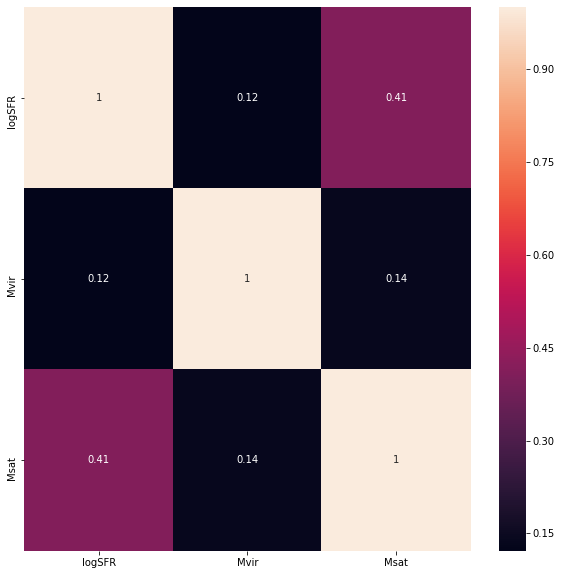

<Figure size 432x288 with 0 Axes>

In [7]:
method = "spearman"
X_corr = GetCorrMatrix(dataset_orig,LabelNames_orig,method=method)

In [7]:
for i,x in enumerate(LabelNames_orig):
    print(i,x)

0 logSFR
1  logM
2  logdMdt


In [13]:
### Decision Tree analysis ###
### Create decision tree to get feature importance ###


def GetFeatureImportance(dataset, LabelNames_orig):
    Ntot = np.shape(dataset)[0]
    
    y = dataset[:,0] #What we want to predict. Assuming SFR in column 0
    #make labels binary: split 50%/50%
    y_median = np.median(y)
    for i in range(Ntot):
        if(y[i] < y_median):
            y[i] = -1
        else:
            y[i] = 1
    #all other colums are features
    X = dataset[:,1:]
    LabelNames_orig = LabelNames_orig[1:]
    
    
    FI_sum = 0
    acc_sum = 0.
    N_sum = 0



    #Split the data into a training and a testing set

    Ntrain = int(0.9*Ntot)
    print("Ntrain=",Ntrain)

    train_features = X[:Ntrain,:]
    test_features = X[Ntrain:,:]
    train_targets = y[:Ntrain]
    test_targets = y[Ntrain:]


    #Train the model
    tree = DecisionTreeClassifier(criterion = 'gini',max_depth=8).fit(train_features,train_targets)
    FI_now = np.array(tree.feature_importances_)

    #Predict the classes of new, unseen data
    prediction = tree.predict(test_features)

    #Check the accuracy
    acc = tree.score(test_features,test_targets)
    acc = int(100*acc)
    print("The prediction accuracy is: ",acc,"%")


    #plot decision tree
    if(False):
        dot_file = 'tree.dot'
        skl.tree.export_graphviz(tree, out_file=dot_file, feature_names=LabelNames_orig)
        call(['dot', '-T', 'png', dot_file, '-o', 'v1_acc_'+str(acc)+'_tree.png'])


   # FI_sum = FI_sum#/np.sum(FI_sum)#option to normalise feature importance
    print("Feature Importance:")
    for i,label in enumerate(LabelNames_orig):
        print(label,np.round(100*FI_now[i],2),"%")
    print(" ")
    return prediction, 100*FI_now

In [14]:
prediction, FI = GetFeatureImportance(np.copy(dataset_orig), LabelNames_orig)

Ntrain= 1176
The prediction accuracy is:  80 %
Feature Importance:
Mvir 29.99 %
Msat 70.01 %
 


In [1]:
prediction

NameError: name 'prediction' is not defined